# Algorithm Comparison

Side-by-side comparison of alternative algorithms at each pipeline stage:
- Pre-filters: EPSF vs PGF vs vectoral median
- Watershed inputs: H-image vs MSGM
- Merging methods: RM1 vs RM2 vs RM3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from watershed_seg.filters import epsf, pgf, vectoral_median
from watershed_seg.watershed_input import h_image, msgm
from watershed_seg.watershed import vincent_soille
from watershed_seg.merging import rm1, rm2, rm3
from watershed_seg.evaluation import psnr, simplified_image

rng = np.random.default_rng(0)
img = np.zeros((64, 64, 3), dtype=np.float64)
img[:32, :32] = rng.uniform(200, 220, (32, 32, 3))
img[:32, 32:] = rng.uniform(50,  70,  (32, 32, 3))
img[32:, :32] = rng.uniform(100, 120, (32, 32, 3))
img[32:, 32:] = rng.uniform(150, 170, (32, 32, 3))

## Pre-filter comparison

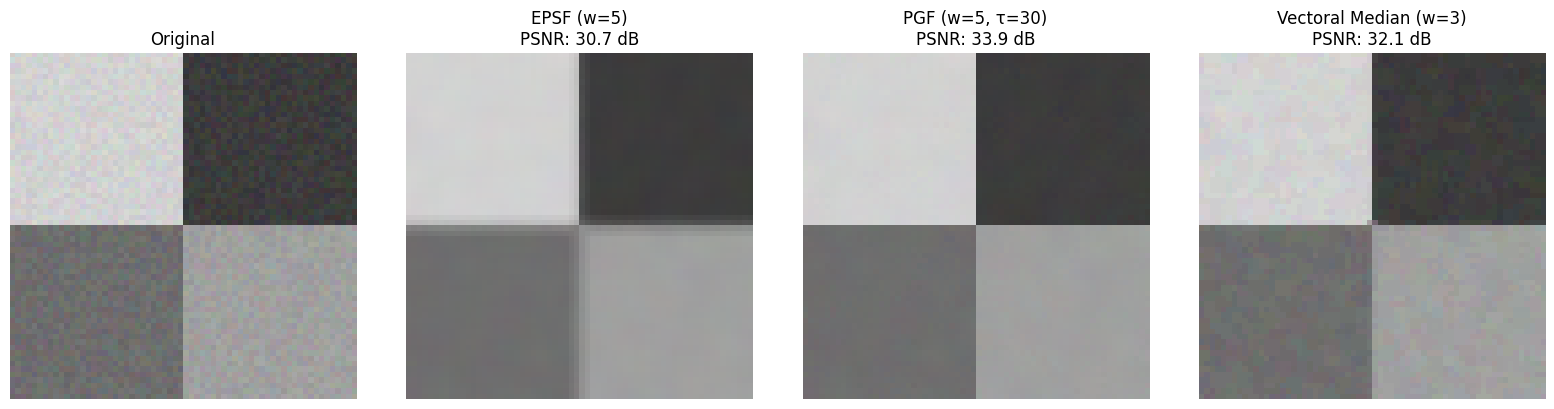

In [2]:
filters = [
    ('Original', img),
    ('EPSF (w=5)', epsf(img, w=5)),
    ('PGF (w=5, τ=30)', pgf(img, w=5, tau=30.0)),
    ('Vectoral Median (w=3)', vectoral_median(img, w=3)),
]

fig, axes = plt.subplots(1, len(filters), figsize=(16, 4))
for ax, (name, fimg) in zip(axes, filters):
    ax.imshow(fimg.astype(np.uint8))
    p = psnr(img, fimg) if name != 'Original' else float('inf')
    ax.set_title(f'{name}\nPSNR: {p:.1f} dB' if p != float('inf') else name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Watershed input comparison

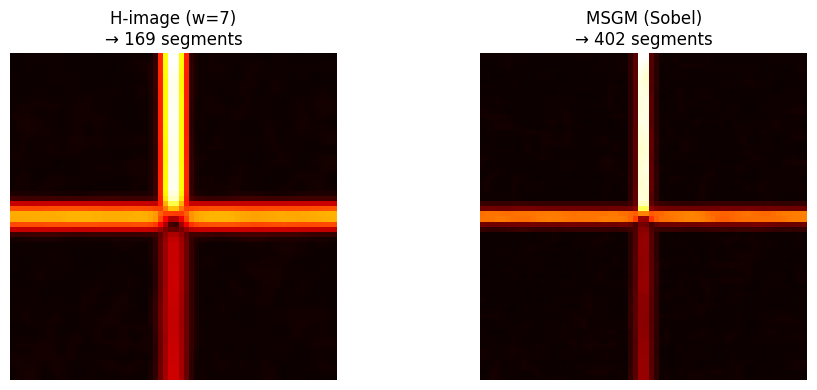

In [3]:
filtered = epsf(img, w=5)
h_img = h_image(filtered, w=7)
grad_img = msgm(filtered)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(h_img, cmap='hot')
axes[0].set_title(f'H-image (w=7)\n→ {vincent_soille(h_img).max()} segments')
axes[0].axis('off')
axes[1].imshow(grad_img, cmap='hot')
axes[1].set_title(f'MSGM (Sobel)\n→ {vincent_soille(grad_img).max()} segments')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Region merging method comparison

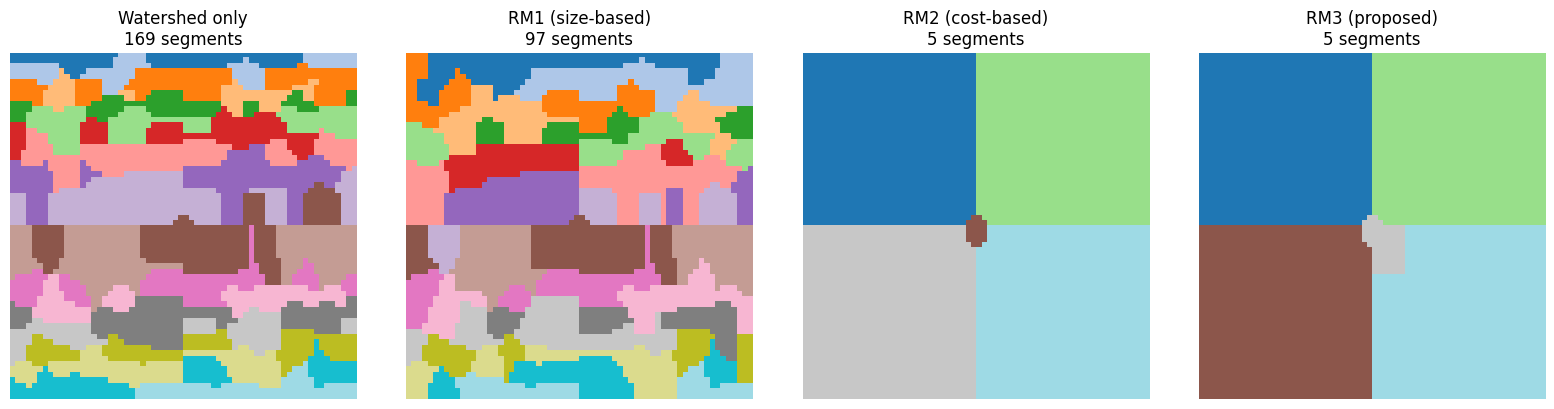

In [4]:
ws_labels = vincent_soille(h_img)

rm1_labels = rm1(ws_labels, img, size_threshold=20)
rm2_labels = rm2(ws_labels, img, cost_threshold=500)
rm3_labels = rm3(ws_labels, img, size_threshold=20, cost_threshold=500)

methods = [
    ('Watershed only', ws_labels),
    ('RM1 (size-based)', rm1_labels),
    ('RM2 (cost-based)', rm2_labels),
    ('RM3 (proposed)', rm3_labels),
]

fig, axes = plt.subplots(1, len(methods), figsize=(16, 4))
for ax, (name, lbl) in zip(axes, methods):
    ax.imshow(lbl, cmap='tab20')
    ax.set_title(f'{name}\n{lbl.max()} segments')
    ax.axis('off')
plt.tight_layout()
plt.show()